# All computations

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_surface_variance, compute_surface_roughness, compute_height_height_correlations, compute_structure_factor, compute_phase_covariance

In [2]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"Columnar": {"EW": 3/2, "KPZ": 1.4}} # anomalous scaling, only for columnar noise
alpha_loc_dict = {"Columnar": {"KPZ": 0.97}} # anomalous scaling, only for columnar noise in the KPZ case
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

### 2. Roughness

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        # # Restrict the computation to data of a given length
        # if typenoise == "Columnar":
        #     new_df = df[~(df["phases"].apply(lambda arr: arr.shape[0] == 27))]

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [4]:
# Note: we start from scratch the average DataFrame (each time this script is run)
avg_df = pd.DataFrame()
avg_df_path = "AverageSims.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print("Saved AverageSims to:", avg_df_path)

Saved AverageSims to: AverageSims.pkl


In [7]:
avg_df[(avg_df["K"] == 20) & (avg_df["T"] == 20000)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight
avg_id,,,,,,,,,,,
Columnar_delta0_L125_K20.0_T20000_M200,Columnar,0.000000,0,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",200,20000,"[0.0, 0.14211780522175843, 0.19700187898423172...","[0.0, 0.14491166998027283, 0.20194255816037937...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L250_K20.0_T20000_M457,Columnar,0.000000,0,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",457,20000,"[0.0, 0.14726257028696876, 0.206085076909872, ...","[0.0, 0.14852566605196862, 0.2083641682374369,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L500_K20.0_T20000_M430,Columnar,0.000000,0,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",430,20000,"[0.0, 0.15117305657918037, 0.21282600391954395...","[0.0, 0.15184674700609221, 0.21403775150603213...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L1000_K20.0_T20000_M505,Columnar,0.000000,0,20.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",505,20000,"[0.0, 0.1521718275463539, 0.2149099616368219, ...","[0.0, 0.1524993882938343, 0.2155149673633728, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L125_K20.0_T20000_M444,Columnar,1.373401,atan5,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",444,20000,"[0.0, 0.22292159456595645, 0.3054045323983475,...","[0.0, 0.2246243048194169, 0.3084011109842398, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L250_K20.0_T20000_M468,Columnar,1.373401,atan5,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",468,20000,"[0.0, 0.22738818294732252, 0.31273919165137265...","[0.0, 0.22823772573209508, 0.31427011004782035...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L500_K20.0_T20000_M356,Columnar,1.373401,atan5,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",356,20000,"[0.0, 0.23001848117225157, 0.3171881836918727,...","[0.0, 0.23038390187674862, 0.31788337331380656...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_deltaatan5_L1000_K20.0_T20000_M262,Columnar,1.373401,atan5,20.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",262,20000,"[0.0, 0.23048765247510317, 0.31842345757759766...","[0.0, 0.23067580249951875, 0.3187661700488755,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


### 3. Height-height correlations (takes the longest)

In [5]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        heightheight_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            heightheight = np.asarray(compute_height_height_correlations(phases), dtype=float)

            heightheight_list.append(heightheight)

        # Avoid chained-assignment issues
        df = df.copy()
        df["heightheight"] = heightheight_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE HEIGHT-HEIGHT CORRELATION PER (K, L, T) ##
        # group by K, L, T and compute mean height-height correlation for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            heightheight_arrays = [np.asarray(r, dtype=float) for r in group["heightheight"]]
            mean_heightheight = np.mean(np.stack(heightheight_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_heightheight": mean_heightheight,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [6]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_heightheight"] = new_avg["mean_heightheight"]

avg_df.to_pickle(avg_df_path)

### 4. Structure Factor

In [8]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        structurefactor_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            structurefactor = np.asarray(compute_structure_factor(phases), dtype=float)

            structurefactor_list.append(structurefactor)

        # Avoid chained-assignment issues
        df = df.copy()
        df["structurefactor"] = structurefactor_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE STRUCTURE FACTOR PER (K, L, T) ##
        # group by K, L, T and compute mean structure factor for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            structurefactor_arrays = [np.asarray(r, dtype=float) for r in group["structurefactor"]]
            mean_structurefactor = np.mean(np.stack(structurefactor_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_structurefactor": mean_structurefactor,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [9]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_structurefactor"] = new_avg["mean_structurefactor"]

avg_df.to_pickle(avg_df_path)

### 5. Phase covariance (takes long as well)

In [10]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        phasecovariance_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            phasecovariance = np.asarray(compute_phase_covariance(phases), dtype=float)

            phasecovariance_list.append(phasecovariance)

        # Avoid chained-assignment issues
        df = df.copy()
        df["phasecovariance"] = phasecovariance_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            phasecovariance_arrays = [np.asarray(r, dtype=float) for r in group["phasecovariance"]]
            mean_phasecovariance = np.mean(np.stack(phasecovariance_arrays, axis=0), axis=0)

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [11]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

### 6. Phase fluctuations

## Inspection of the computed quantities

In [3]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

In [4]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [5]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

In [6]:
T = 20000
L = 500

### 2. Roughness

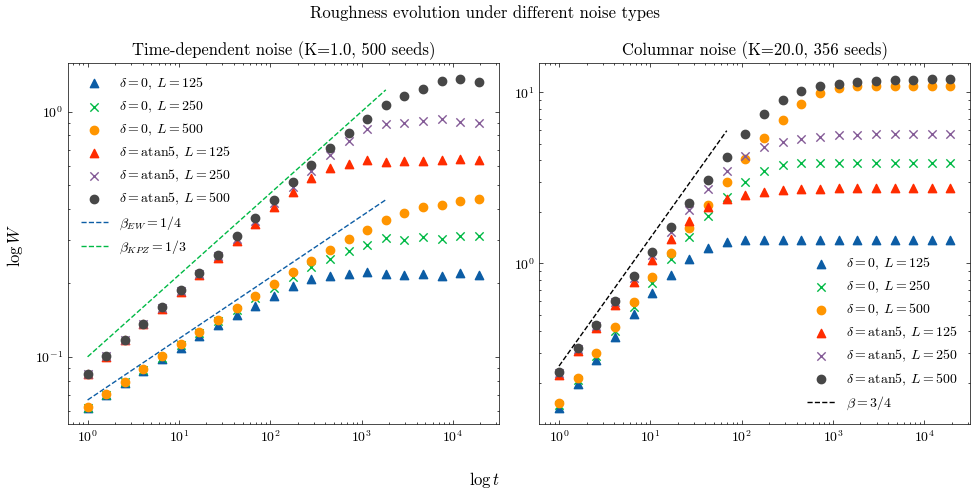

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle("Roughness evolution under different noise types")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):

    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
            & (avg_df["T"] == 20000)
            & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # if typenoise == "Columnar":
        #     mask = (avg_df["T"] == 200000)
        #     sub_df = sub_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
            M = row["M"]
            # print(np.round(t))

            ax[i].scatter(t, mean_roughness, label=r"$\delta=$" + deltaname + r", $L=$" + str(L), marker=markerdict[L])
            ax[i].set_title(typelabel+ f" (K={K}, {M} seeds)")

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xscale('log')


# Scalings
ax[0].loglog(t[1:-5:], t[1:-5:]**(beta_dict["TimeDep"]["EW"]) /15, label=r"$\beta_{EW}=1/4$", linestyle="--")
ax[0].loglog(t[1:-5:], t[1:-5:]**(beta_dict["TimeDep"]["KPZ"]) /10, label=r"$\beta_{KPZ}=1/3$", linestyle="--")

ax[1].loglog(t[1:-12:], t[1:-12:]**(beta_dict["Columnar"]["EW"]) / 4, label=r"$\beta=3/4$", linestyle="--", color="k")
# ax[1].loglog(t[1::], t[1::]**(1) , label=r"$\beta=1$ ??", linestyle="--", color="k")

ax[0].legend()
ax[1].legend()

# ax[0].set_xlim(0, 2e4)
# ax[1].set_xlim(0, 2e4)

plt.tight_layout()
plt.show()

#### Family-Vicsek collapse

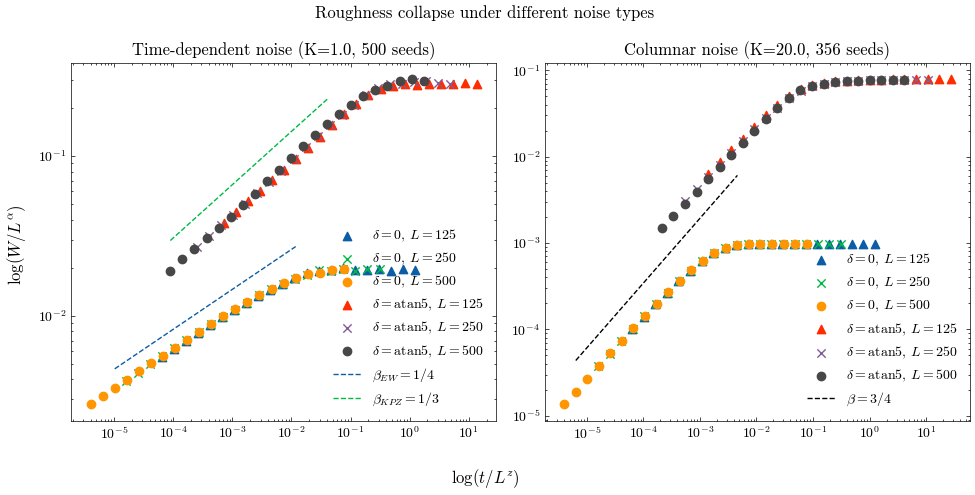

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle("Roughness collapse under different noise types")

fig.supxlabel(r"$\log (t/L^z)$")
fig.supylabel(r"$\log (W / L^\alpha)$")

## EXPONENTS: 

for i, (typenoise, typelabel, alpha) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"], [1/2, 1])
):

    for delta, deltaname, z in zip([0, np.arctan(5)], ["0", "atan5"], [3/2, 2]):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
            & (avg_df["T"] == T)
            & (avg_df["L"] < 1000)
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            # Collapse variables
            tLz = t / L**(z_dict[typenoise][delta_to_label[deltaname]])
            WLa = mean_roughness / L**(alpha_dict[typenoise][delta_to_label[deltaname]])

            if deltaname == "atan5":
                WLa *= 5
            
            ax[i].scatter(tLz, WLa, label=r"$\delta=$" + deltaname + r", $L=$" + str(L), marker=markerdict[L])
            ax[i].set_title(typelabel+ f" (K={K}, {M} seeds)")

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[0].loglog(t[3:-4:] / L**(z_dict["TimeDep"]["EW"]), (t[3:-4:] / L ** (alpha_dict["TimeDep"]["EW"])) **(beta_dict["TimeDep"]["EW"]) /125, label=r"$\beta_{EW}=1/4$", linestyle="--")
ax[0].loglog(t[1:-8:] / L**(z_dict["TimeDep"]["KPZ"]), (t[1:-8:] / L ** (alpha_dict["TimeDep"]["KPZ"])) **(beta_dict["TimeDep"]["KPZ"]) /12, label=r"$\beta_{KPZ}=1/3$", linestyle="--")

ax[1].loglog(t[2:-6:] / L**(z_dict["Columnar"]["EW"]), (t[2:-6:] / L ** (alpha_dict["Columnar"]["EW"])) **(beta_dict["Columnar"]["EW"]) /30, label=r"$\beta=3/4$", linestyle="--", color="k")
# ax[1].loglog(t[1:-14:] / L**(3/2), (t[1:-14:] / L ** (1/2)) **(1) /20, label=r"$\beta=1$ ??", linestyle="--", color="k")

ax[0].legend()
ax[1].legend()


plt.tight_layout()
plt.show()

### 3. Height-height correlations

/tmp/ipykernel_72086/764064934.py:35: RuntimeWarning: divide by zero encountered in divide
  rt1z = rrange[:int(rlen/2)] / ti**(1/z_dict[typenoise][delta_to_label[deltaname]])
/tmp/ipykernel_72086/764064934.py:35: RuntimeWarning: invalid value encountered in divide
  rt1z = rrange[:int(rlen/2)] / ti**(1/z_dict[typenoise][delta_to_label[deltaname]])
/tmp/ipykernel_72086/764064934.py:36: RuntimeWarning: invalid value encountered in divide
  Gt2az =mean_heightheight[ti,:int(rlen/2)] / ti**(2*beta_dict[typenoise][delta_to_label[deltaname]])


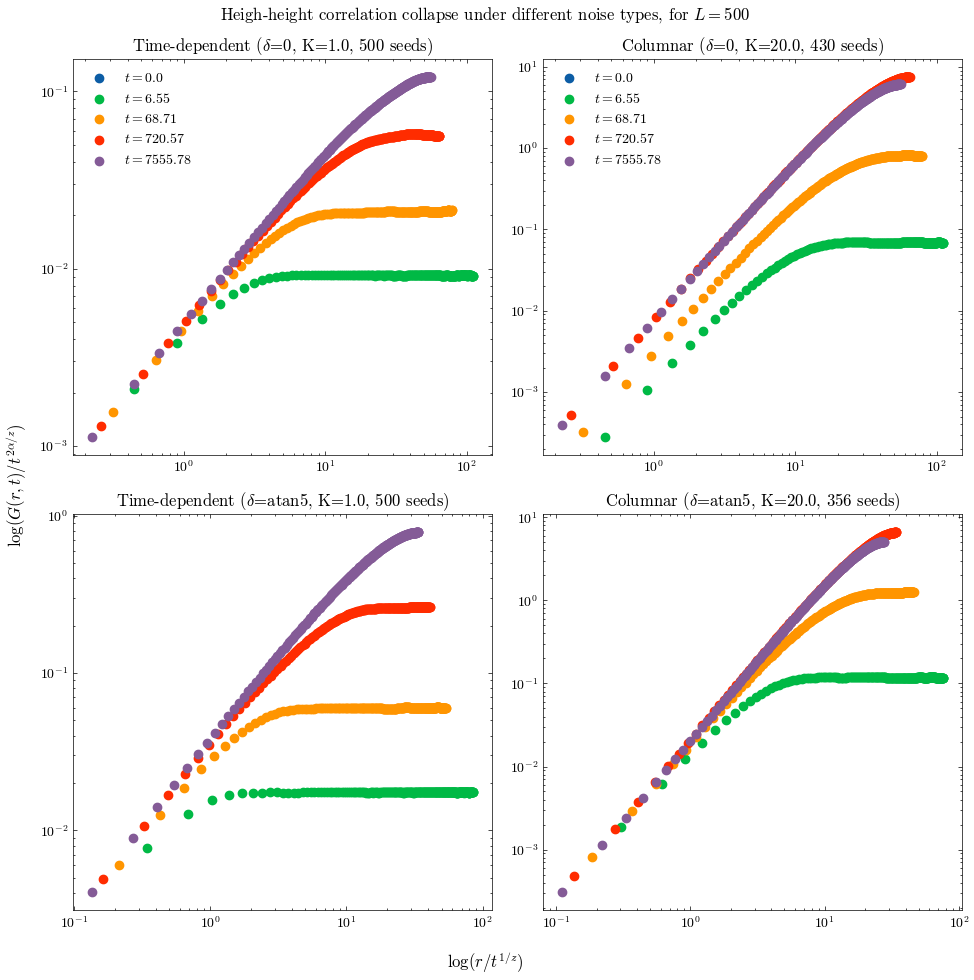

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Heigh-height correlation collapse under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$\log (r/ t^{1/z})$")
fig.supylabel(r"$\log (G(r,t)/ t^{2\alpha/z})$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_heightheight = row["mean_heightheight"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            for ti in range(mean_heightheight.shape[0])[::5]:
                rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                rrange = np.array(range(rlen))

                # Collapse variables
                rt1z = rrange[:int(rlen/2)] / ti**(1/z_dict[typenoise][delta_to_label[deltaname]])
                Gt2az = mean_heightheight[ti,:int(rlen/2)] / ti**(2*beta_dict[typenoise][delta_to_label[deltaname]])

                ax[j,i].scatter(rt1z, Gt2az, label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
                
            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds)")

ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')
ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')
ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')

# scaling as r^(2\alpha) = r^1 for alpha = 1/2 (EW/KPZ)
# ax[0,0].loglog(rrange[1:int(rlen/4)], rrange[1:int(rlen/4)]**(2*alpha_dict["TimeDep"]["EW"]) /140, label=r"$\alpha_{EW}=\beta_{KPZ}=1/2$", linestyle="--", color="k")
# ax[1,0].loglog(rrange[1:int(rlen/4)], rrange[1:int(rlen/4)]**(2*alpha_dict["TimeDep"]["KPZ"])/15, linestyle="--", color="k")

# scaling as r^(2\alpha) = r^2 for alpha_loc approx 1 (EW/KPZ)
# ax[0,1].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_dict["Columnar"]["EW"])/5, label=r"$\alpha_{loc}=1$", linestyle="--", color="k")
# ax[1,1].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_dict["Columnar"]["KPZ"]) * 20, linestyle="--", color="k")

ax[0,0].legend()
ax[0,1].legend()

plt.tight_layout()
plt.show()

### 4. Structure factor

/tmp/ipykernel_67420/1152568693.py:57: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,0].set_ylim(0,1e3)


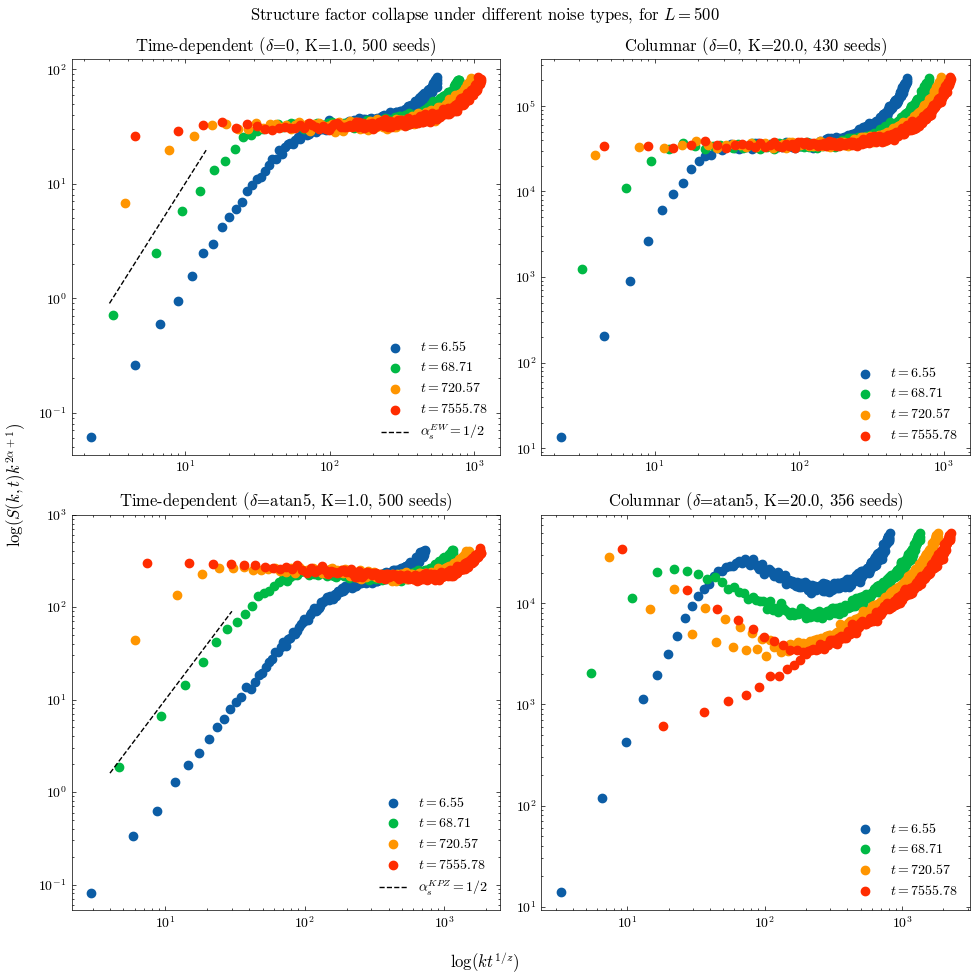

In [23]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Structure factor collapse under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$\log (k t^{1/z})$")
fig.supylabel(r"$\log (S(k,t) k^{2\alpha+1})$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]            
            mean_structurefactor = row["mean_structurefactor"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            for ti in range(mean_structurefactor.shape[0])[::5]:
                if ti == 0:
                    continue
                klen = mean_structurefactor.shape[1] # we only plot up to half due to nyquist
                krange = np.array(range(klen))
                ax[j,i].scatter(krange[:int(klen/2)] * ti**(1/z_dict[typenoise][delta_to_label[deltaname]]),
                                mean_structurefactor[ti,:int(klen/2)] * krange[:int(klen/2)]**(2*alpha_dict[typenoise][delta_to_label[deltaname]]+1),
                                label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds)")

ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')
ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')
ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')

# scaling as y^(2*alpha+1) = k^2 for alpha = 1/2 (EW/KPZ)
ax[0,0].loglog(krange[3:int(klen/32)], krange[3:int(klen/32)]**(2*alpha_dict["TimeDep"]["EW"]+1) / 10, label=r"$\alpha_s^{EW}=1/2$", linestyle="--", color="k")
ax[1,0].loglog(krange[4:int(klen/16)], krange[4:int(klen/16)]**(2*alpha_dict["TimeDep"]["KPZ"]+1) / 10, label=r"$\alpha_s^{KPZ}=1/2$", linestyle="--", color="k")

# scaling as k^(-2*alpha_s-1) for alpha_s approx 3/2 (EW) or 1.4 (KPZ)
# ax[0,1].loglog(krange[2:int(klen/16)], krange[2:int(klen/16)]**(-2*alpha_dict["Columnar"]["EW"]-1) * 100000, label=r"$\alpha_s^{EW}=3/2,\,\alpha_s^{KPZ}=1.4$", linestyle="--", color="k")
# ax[1,1].loglog(krange[2:int(klen/16)], krange[2:int(klen/16)]**(-2*alpha_dict["Columnar"]["KPZ"]-1) * 5000000, linestyle="--", color="k")

ax[1,0].set_ylim(0,1e3)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

### 5. Phase covariance

### 6. Phase fluctuations